In [2]:
!pip install trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [3]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from trl import DPOTrainer, DPOConfig

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
# 10 toy preference pairs
data = {
    "prompt":   ["Summarize: " + "text " * 5] * 10,
    "chosen":   ["Good summary."] * 10,
    "rejected": ["Bad."] * 10,
}
dataset = Dataset.from_dict(data)
margins = {}


In [6]:

for beta in [0.01, 0.1, 0.5]:
    model = AutoModelForCausalLM.from_pretrained(model_name)
    ref   = AutoModelForCausalLM.from_pretrained(model_name)
    cfg   = DPOConfig(beta=beta, max_steps=30, output_dir=f"dpo_beta_{beta}",
                      per_device_train_batch_size=2, logging_steps=5)
    trainer = DPOTrainer(model=model, ref_model=ref, args=cfg,
                     train_dataset=dataset, processing_class=tokenizer)
    trainer.train()
    margins[beta] = trainer.state.log_history  # contains rewards/margins


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Adding EOS to train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

...

Adding EOS to train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Step,Training Loss
5,0.583666
10,0.366114
15,0.256959
20,0.182635
25,0.154916
30,0.099613


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

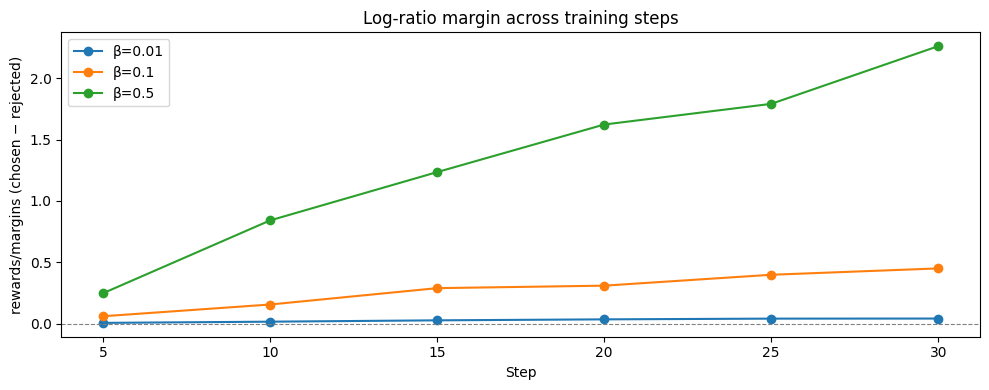

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

for beta, history in margins.items():
    steps = [e["step"] for e in history if "rewards/margins" in e]
    vals  = [e["rewards/margins"] for e in history if "rewards/margins" in e]
    ax.plot(steps, vals, marker='o', label=f'β={beta}')

ax.set(title='Log-ratio margin across training steps',
       xlabel='Step', ylabel='rewards/margins (chosen − rejected)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig('beta_margins.png', dpi=150)


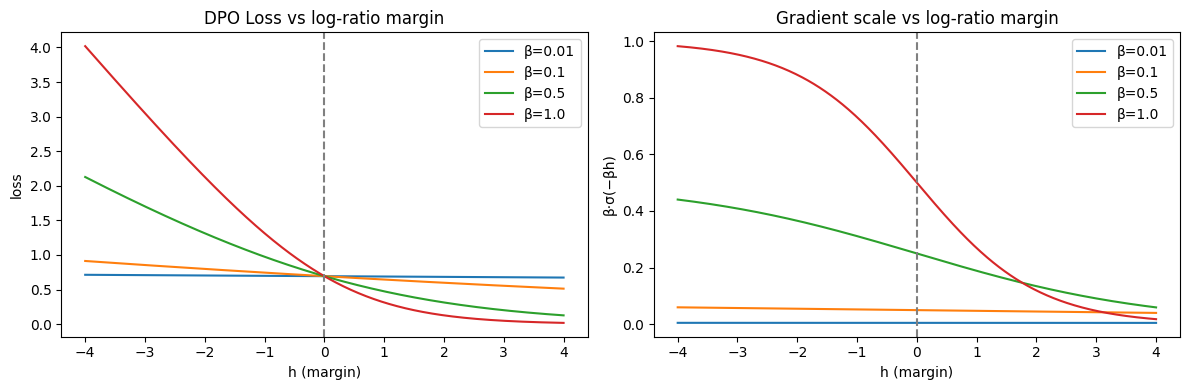

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

h = np.linspace(-4, 4, 500)  # log-ratio margin (chosen - rejected, relative to ref)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for beta in [0.01, 0.1, 0.5, 1.0]:
    loss = -np.log(sigmoid(beta * h))
    grad = beta * sigmoid(-beta * h)   # ∂L/∂θ scaling factor
    ax1.plot(h, loss, label=f'β={beta}')
    ax2.plot(h, grad, label=f'β={beta}')

ax1.set(title='DPO Loss vs log-ratio margin', xlabel='h (margin)', ylabel='loss')
ax2.set(title='Gradient scale vs log-ratio margin', xlabel='h (margin)', ylabel='β·σ(−βh)')
for ax in (ax1, ax2): ax.legend(); ax.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.savefig('beta_comparison.png', dpi=150)
